# Métodos Iterativos
todos os métodos de resolução de sistemas lineares que vimos até agora foram métodos exatos, agora vamos ver os iterativos

## condições de convergência


## condições de convergência

Para métodos iterativos (Jacobi, Gauss–Seidel, SOR) uma condição simples e suficiente para convergência é a **dominância diagonal** ou, mais geral, que a matriz iterativa tenha raio espectral < 1.

Definimos os coeficientes locais \(\alpha_i\) que aparecem frequentemente nas condições:

- Para a linha 1 do exemplo (com 3 variáveis):
  \[
  \alpha_1 = \frac{|a_{12}| + |a_{13}|}{|a_{11}|},
  \]

- Para a linha 2:
  \[
  \alpha_2 = \frac{|a_{21}| + |a_{23}|}{|a_{22}|},
  \]

Em geral, para linha \(i\):
  \[
  \alpha_i = \frac{\sum_{j\neq i} |a_{ij}|}{|a_{ii}|}.
  \]

Se \(\max_i \alpha_i < 1\) então a matriz é estritamente diagonal dominante por linha e os métodos iterativos (Jacobi e Gauss–Seidel) convergem.

Observações:
- Dominância diagonal por linha (\(|a_{ii}| > \sum_{j\ne i} |a_{ij}|\,\) para todo \(i\)) é uma condição suficiente, mas não necessária.
- Outra condição mais geral usa o raio espectral da matriz de iteração \(\rho(B)<1\).
- Para SOR usamos também o parâmetro de relaxação \(\omega\) e a condição fica dependente de \(\omega\) e da matriz original.

Exemplo rápido (a imagem):
\(\alpha_1 = (|a_{12}|+|a_{13}|)/|a_{11}|\) e \(\alpha_2 = (|a_{21}|+|a_{23}|)/|a_{22}|\) como mostrado.

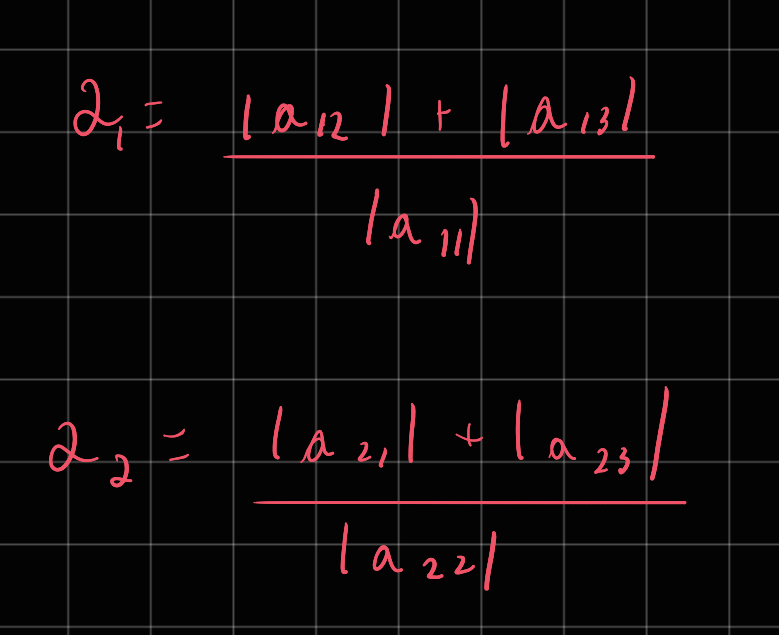

In [ ]:
import numpy as np

e = 1e-2 # precision
x = np.array([[0.7], [-1.6], [0.6]])  # chute inicial

# gauss-jacobbi method
A = np.array([
    [10, 2, 1], 
    [1, 5, 1], 
    [2, 3, 10]], dtype=float)

B = np.array([
    [7],
    [-8],
    [6]], dtype=float)

# vars
n = len(B)
x_old = x.copy()
i = 0

while True:
    x_new = np.zeros_like(x_old)

    for i in range(n):
        s = sum(A[i][j] * x_old[j] for j in range(n) if j != i)
        x_new[i] = (B[i] - s) / A[i][i]

    # verifica critério de parada
    if np.linalg.norm(x_new - x_old, ord=np.inf) < e:
        break

    x_old = x_new.copy()
    i += 1

print(f"Solução aproximada após {i} iterações:")
print(x_new)




Solução aproximada após 2 iterações:
[[ 1.000236]
 [-1.998936]
 [ 1.000284]]


In [15]:
import numpy as np

# ----------------------------------------------
# MÉTODO DE GAUSS–JACOBI
# ----------------------------------------------
# Sistema linear:
# A * x = B
#
# O método de Gauss–Jacobi calcula uma aproximação
# iterativa para o vetor x.
#
# Fórmula:
# x_i^(k+1) = (b_i - Σ (a_ij * x_j^(k)) ) / a_ii
# ----------------------------------------------

# Precisão desejada (erro máximo permitido)
e = 1e-2

# Chute inicial (valores iniciais para x1, x2 e x3)
x0 = np.array([[0.7],
               [-1.6],
               [0.6]])

# Matriz dos coeficientes A
A = np.array([
    [10, 2, 1],
    [1, 5, 1],
    [2, 3, 10]
], dtype=float)

# Vetor de termos independentes B
B = np.array([
    [7],
    [-8],
    [6]
], dtype=float)

# Número de variáveis (tamanho do sistema)
n = len(B)

# Vetores para armazenar os valores atuais e os anteriores
x_ant = x0.copy()
x_novo = np.zeros_like(x_ant)

# Contador de iterações
k = 0

# Loop principal — repete até a diferença entre iterações ser pequena
while True:
    k += 1  # conta a iteração atual
    
    # Calcula cada componente x_i
    for i in range(n):
        soma = 0
        
        # Soma dos termos A[i][j] * x_ant[j], exceto j = i
        for j in range(n):
            if j != i:
                soma += A[i][j] * x_ant[j]
        
        # Fórmula do método de Jacobi
        x_novo[i] = (B[i] - soma) / A[i][i]
    
    # Calcula o erro (diferença máxima entre iterações)
    erro = np.max(np.abs(x_novo - x_ant))
    
    # Mostra o progresso de cada iteração
    print(f"Iteração {k}: x = {x_novo.ravel()}, erro = {erro:.4f}")
    
    # Verifica o critério de parada
    if erro < e:
        break
    
    # Atualiza o vetor anterior
    x_ant = x_novo.copy()

# Exibe o resultado final
print("\nSolução aproximada encontrada:")
print(x_novo)
print(f"Número total de iterações: {k}")

Iteração 1: x = [ 0.96 -1.86  0.94], erro = 0.3400
Iteração 2: x = [ 0.978 -1.98   0.966], erro = 0.1200
Iteração 3: x = [ 0.9994 -1.9888  0.9984], erro = 0.0324
Iteração 4: x = [ 0.99792 -1.99956  0.99676], erro = 0.0108
Iteração 5: x = [ 1.000236 -1.998936  1.000284], erro = 0.0035

Solução aproximada encontrada:
[[ 1.000236]
 [-1.998936]
 [ 1.000284]]
Número total de iterações: 5


In [ ]:
#Gauss-Seidel Method
import numpy as np
# Precisão desejada (erro máximo permitido)
e = 1e-2

# Chute inicial (valores iniciais para x1, x2 e x3)
x = np.array([[0.7],
               [-1.6],
               [0.6]])

# Matriz dos coeficientes A
A = np.array([
    [10, 2, 1],
    [1, 5, 1],
    [2, 3, 10]
], dtype=float)

# Vetor de termos independentes B
B = np.array([
    [7],
    [-8],
    [6]
], dtype=float)

# Número de variáveis (tamanho do sistema)
n = len(B)

# Vetores para armazenar os valores atuais e os anteriores
x_ant = x0.copy()
x_novo = np.zeros_like(x_ant)

# Contador de iterações
k = 0

while True:
    k += 1  
    x_ant = x.copy()
    
    for i in range(n):
        soma = 0
        
        for j in range(n):
            if j != i:
                soma += A[i][j] * x[j]
        
        x[i] = (B[i] - soma) / A[i][i]
    
    erro = np.max(np.abs(x - x_ant))
    
    print(f"Iteração {k}: x = {x.ravel()}, erro = {erro:.4f}")
    
    # Verifica o critério de parada
    if erro < e:
        break
    
# Exibe o resultado final
print("\nSolução aproximada encontrada:")
print(x)
print(f"Número total de iterações: {k}")



Iteração 1: x = [ 0.96   -1.912   0.9816], erro = 0.3816
Iteração 2: x = [ 0.98424   -1.993168   1.0011024], erro = 0.0812
Iteração 3: x = [ 0.99852336 -1.99992515  1.00027287], erro = 0.0143
Iteração 4: x = [ 0.99995774 -2.00004612  1.00002229], erro = 0.0014

Solução aproximada encontrada:
[[ 0.99995774]
 [-2.00004612]
 [ 1.00002229]]
Número total de iterações: 4
